# Semana 2B: GridWorld 4×4

## T1: Implementar GridWorld 4×4

Clase Python · Estados · Acciones · Transiciones Estocásticas · Recompensas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


class GridWorld:
    def __init__(self, rows=4, cols=4, gamma=0.9):
        self.rows, self.cols = rows, cols
        self.n_states = rows * cols
        self.n_actions = 4  # 0=↑  1=↓  2=←  3=→
        self.gamma = gamma
        self.goal = 15  # s15: esquina inferior derecha
        self.obstacle = 6  # s6:  celda bloqueada
        self.start = 0  # s0:  esquina superior izquierda
        self.action_effects = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # posibles movimientos
        self._build_transitions()

    def _state(self, r, c):
        return r * self.cols + c

    def _rc(self, s):
        return divmod(s, self.cols)

    def _build_transitions(self):
        # P[s, a, s'] = probabilidad de ir a s' desde s con accion a
        self.P = np.zeros((self.n_states, self.n_actions, self.n_states))
        self.R = np.full(self.n_states, -1.0)  # -1.0 por paso
        self.R[self.goal] = 10.0  # +10 en la meta

        for s in range(self.n_states):
            if s == self.goal or s == self.obstacle:
                self.P[s, :, s] = 1.0  # estados absorbentes
                continue
            r, c = self._rc(s)
            for a in range(self.n_actions):
                # accion deseada: 80%  |  perpendiculares: 10% c/u
                perp = [2, 3] if a in [0, 1] else [0, 1]
                for prob, act in [(0.8, a), (0.1, perp[0]), (0.1, perp[1])]:
                    dr, dc = self.action_effects[act]
                    nr, nc = r + dr, c + dc
                    # si sale del grid o choca con obstáculo → queda en s
                    if (
                        0 <= nr < self.rows
                        and 0 <= nc < self.cols
                        and self._state(nr, nc) != self.obstacle
                    ):
                        s_next = self._state(nr, nc)
                    else:
                        s_next = s
                    self.P[s, a, s_next] += prob

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        s = self.state
        probs = self.P[s, action]  # distribución sobre s'
        s_next = np.random.choice(self.n_states, p=probs)
        reward = self.R[s_next]
        done = s_next == self.goal
        self.state = s_next
        return s_next, reward, done, {}

    def render(self):
        grid = np.arange(self.n_states).reshape(self.rows, self.cols)
        r, c = self._rc(self.state)
        print(f"Estado actual: s{self.state} (fila {r}, col {c})")
        print(grid)


# ── PRUEBA RÁPIDA ──────────────────────────────────────
env = GridWorld(gamma=0.9)
obs = env.reset()
print(f"Estado inicial: {obs}")
obs, r, done, _ = env.step(3)  # → intenta ir a la derecha
print(f"s'={obs}, r={r:.1f}, done={done}")

Estado inicial: 0
s'=1, r=-1.0, done=False


## T2: Simular Política Aleatoria y Retorno Empírico


γ=0.70  →  G medio=-3.28  ±0.23
γ=0.90  →  G medio=-8.67  ±2.61
γ=0.99  →  G medio=-42.04  ±25.82


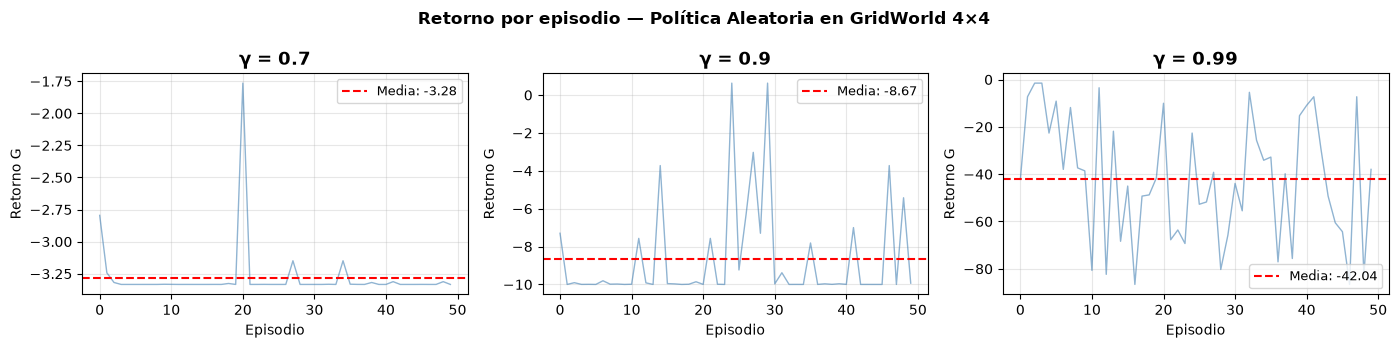

In [2]:
def run_episode(env, policy="random", max_steps=200):
    """Corre un episodio, devuelve lista de (s, a, r)."""
    obs = env.reset()
    trajectory = []
    for _ in range(max_steps):
        if policy == "random":
            action = np.random.randint(env.n_actions)
        obs_next, reward, done, _ = env.step(action)
        trajectory.append((obs, action, reward))
        obs = obs_next
        if done:
            break
    return trajectory


def compute_return(trajectory, gamma):
    """Calcula el retorno descontado desde t=0."""
    G = 0
    for _, _, r in reversed(trajectory):
        G = r + gamma * G
    return G


# ── EXPERIMENTO ───────────────────────────────────────
gammas = [0.7, 0.9, 0.99]
n_eps = 50

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)

for ax, g in zip(axes, gammas):
    env = GridWorld(gamma=g)
    returns = [compute_return(run_episode(env), g) for _ in range(n_eps)]
    print(f"γ={g:.2f}  →  G medio={np.mean(returns):.2f}  ±{np.std(returns):.2f}")

    ax.plot(returns, alpha=0.6, color="steelblue", linewidth=1)
    ax.axhline(
        np.mean(returns),
        color="red",
        linestyle="--",
        label=f"Media: {np.mean(returns):.2f}",
    )
    ax.set_title(f"γ = {g}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Retorno G")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Retorno por episodio — Política Aleatoria en GridWorld 4×4",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## T3: Evaluación de Política Iterativa de Bellman vs Solución Analítica


In [3]:
# def plot_value_function(V, env, title="Función de Valor V(s)", ax=None):
#     grid_V = V.copy()
#     grid_V[env.obstacle] = np.nan  # obstáculo en gris

#     show_plt = False
#     if ax is None:
#         fig, ax = plt.subplots(figsize=(5, 5))
#         show_plt = True

#     cmap = plt.cm.RdYlGn.copy()  # rojo=bajo, verde=alto
#     cmap.set_bad("gray")  # obstáculo en gris

#     im = ax.imshow(
#         grid_V.reshape(env.rows, env.cols),
#         cmap=cmap,
#         vmin=np.nanmin(grid_V),
#         vmax=np.nanmax(grid_V),
#     )
#     plt.colorbar(im, ax=ax, label="V(s)")

#     for s in range(env.n_states):
#         r, c = env._rc(s)
#         label = (
#             "S"
#             if s == env.start
#             else (
#                 "G" if s == env.goal else ("■" if s == env.obstacle else f"{V[s]:.2f}")
#             )
#         )
#         color = "white" if s in [env.start, env.goal] else "black"
#         ax.text(
#             c,
#             r,
#             label,
#             ha="center",
#             va="center",
#             fontsize=11,
#             fontweight="bold",
#             color=color,
#         )

#     ax.set_title(title, fontsize=12, fontweight="bold")
#     ax.set_xticks(range(env.cols))
#     ax.set_yticks(range(env.rows))
#     if show_plt:
#         plt.tight_layout()
#         plt.show()

In [4]:
def plot_value_function(data):
    if not data:
        return

    n_plots = len(data)
    n_cols = 1 if n_plots == 1 else 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False
    )

    for ax, (V, env, title) in zip(axes.flat, data):
        grid_V = V.copy()
        grid_V[env.obstacle] = np.nan  # obstáculo en gris

        cmap = plt.cm.RdYlGn.copy()  # rojo=bajo, verde=alto
        cmap.set_bad("gray")  # obstáculo en gris

        im = ax.imshow(
            grid_V.reshape(env.rows, env.cols),
            cmap=cmap,
            vmin=np.nanmin(grid_V),
            vmax=np.nanmax(grid_V),
        )
        plt.colorbar(im, ax=ax, label="V(s)")

        for s in range(env.n_states):
            r, c = env._rc(s)
            label = (
                "S"
                if s == env.start
                else (
                    "G"
                    if s == env.goal
                    else ("■" if s == env.obstacle else f"{V[s]:.2f}")
                )
            )
            color = "white" if s in [env.start, env.goal] else "black"
            ax.text(
                c,
                r,
                label,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=color,
            )

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xticks(range(env.cols))
        ax.set_yticks(range(env.rows))

    for ax in axes.flat[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return fig, axes

=== Iterativo (γ=0.7) ===
  Convergió en 27 iteraciones

=== Comparación (primeros 8 estados) ===
  Iterativo:  [-3.203 -3.124 -2.972 -2.198 -3.056 -2.839 -3.333  0.524]
  Analítico:  [-3.202 -3.124 -2.971 -2.197 -3.055 -2.838 -3.333  0.525]
  Error max:  3.13e-03
=== Iterativo (γ=0.8) ===
  Convergió en 43 iteraciones

=== Comparación (primeros 8 estados) ===
  Iterativo:  [-4.277 -4.025 -3.562 -1.66  -3.805 -3.26  -5.     3.585]
  Analítico:  [-4.275 -4.023 -3.56  -1.658 -3.803 -3.258 -5.     3.588]
  Error max:  4.25e-03
=== Iterativo (γ=0.9) ===
  Convergió en 89 iteraciones

=== Comparación (primeros 8 estados) ===
  Iterativo:  [-3.312 -2.275 -0.431  5.669 -1.373  0.353 -9.999 18.736]
  Analítico:  [ -3.305  -2.268  -0.424   5.676  -1.366   0.361 -10.     18.744]
  Error max:  9.40e-03
=== Iterativo (γ=0.99) ===

=== Comparación (primeros 8 estados) ===
  Iterativo:  [213.315 221.936 237.109 278.052 229.291 240.405 -63.397 346.756]
  Analítico:  [ 554.957  564.235  580.564  624.3

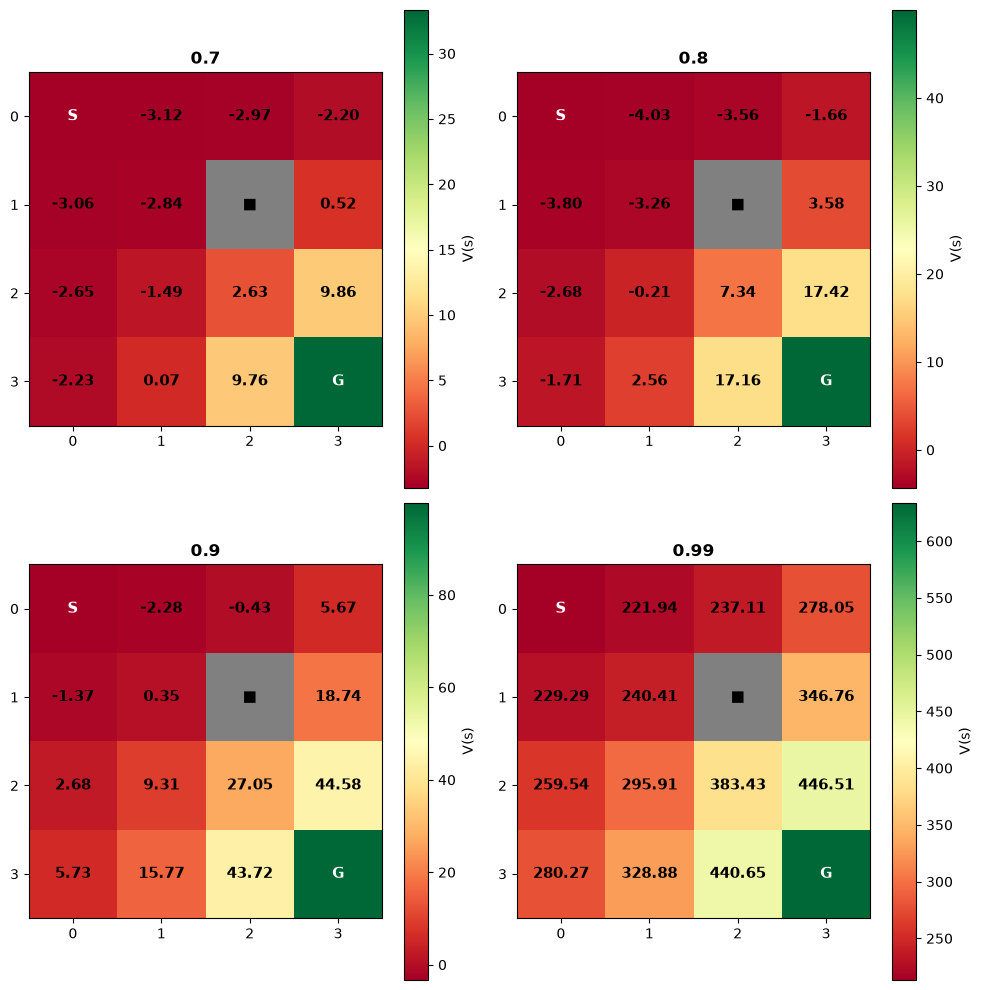

(<Figure size 1000x1000 with 8 Axes>,
 array([[<Axes: title={'center': '0.7'}>, <Axes: title={'center': '0.8'}>],
        [<Axes: title={'center': '0.9'}>,
         <Axes: title={'center': '0.99'}>]], dtype=object))

In [6]:
def policy_evaluation_iterative(env, policy_probs, gamma, tol=1e-3, max_iter=100):
    """
    Evalúa una política fija por iteración de Bellman.
    policy_probs: array (n_states, n_actions) con π(a|s)
    """
    V = np.zeros(env.n_states)  # V₀ = 0 para todo s

    for iteration in range(max_iter):
        V_new = np.zeros(env.n_states)
        for s in range(env.n_states):
            for a in range(env.n_actions):
                # Bellman: Σₐ π(a|s) [R(s,a) + γ Σₛ′ P(s′|s,a)·V(s′)]
                r_sa = env.P[s, a] @ env.R  # recompensa esperada
                v_next = env.P[s, a] @ V  # valor futuro esperado
                V_new[s] += policy_probs[s, a] * (r_sa + gamma * v_next)
        if np.max(np.abs(V_new - V)) < tol:
            print(f"  Convergió en {iteration+1} iteraciones")
            break
        V = V_new
    return V


# ── Política uniforme: π(a|s) = 0.25 para todo a ──────
gamma_eval = [0.7, 0.8, 0.9, 0.99]

data = []

for gamma in gamma_eval:
    env = GridWorld(gamma=gamma)
    pi_uniform = np.ones((env.n_states, env.n_actions)) / env.n_actions

    # Método iterativo
    print(f"=== Iterativo (γ={gamma}) ===")
    V_iter = policy_evaluation_iterative(env, pi_uniform, gamma=gamma)

    # Solución analítica: V = (I - γP_π)⁻¹ R_π
    # P_π[s,s'] = Σₐ π(a|s) P(s'|s,a)
    P_pi = np.einsum("ij,ijk->ik", pi_uniform, env.P)  # (n_s, n_s)
    R_pi = np.einsum("ij,ijk,k->i", pi_uniform, env.P, env.R)
    I = np.eye(env.n_states)
    V_analytic = np.linalg.solve(I - gamma * P_pi, R_pi)

    print("\n=== Comparación (primeros 8 estados) ===")
    print(f"  Iterativo:  {V_iter[:8].round(3)}")
    print(f"  Analítico:  {V_analytic[:8].round(3)}")
    print(f"  Error max:  {np.max(np.abs(V_iter - V_analytic)):.2e}")

    data.append((V_iter, env, gamma))

# plot_value_function(V_iter, env, f"V(s) — Política Aleatoria, γ={gamma}")
plot_value_function(data)

## T4: Análisis de Reflexión y Comparación de Heatmaps (γ=0.7 vs γ=0.99)

Responder a las preguntas del slide.


> Q1: Compara el heatmap de γ=0.7 con γ=0.99. ¿Cómo cambia la forma de V(s)? ¿Por qué los valores absolutos son distintos?

Cuando se aumenta el factor de descuento γ, los valores de V(s) tienden a ser más altos en general, ya que se da más peso a las recompensas futuras. Con γ=0.7, el agente prioriza las recompensas inmediatas, lo que resulta en un heatmap con valores más bajos y menos uniformes. En cambio, con γ=0.99, el agente considera más las recompensas a largo plazo, lo que genera un heatmap con valores más altos y una distribución más uniforme.

> Q2: El estado s₅ (adyacente al obstáculo) tiene V(s₅) bajo. ¿Por qué? ¿Qué efecto tiene el obstáculo en los estados vecinos?

El obstáculo en el GridWorld actúa como una barrera que limita las posibles transiciones desde los estados vecinos. Como resultado, el estado s₅ tiene un valor bajo porque las opciones de acción desde ese estado son limitadas y menos favorables, lo que reduce la expectativa de recompensa futura. Los estados vecinos también se ven afectados negativamente, ya que sus valores dependen de las transiciones hacia s₅, lo que disminuye su valor esperado.

> Q3: ¿Cuántas iteraciones necesitó converger tu evaluación? Prueba con tol=1e-3. ¿Cómo cambia la velocidad vs precisión?

La evaluación convergió en 27 iteraciones con tol=1e-3, γ=0.7. A medida que se reduce la tolerancia, la evaluación se vuelve más precisa, pero también más lenta, ya que se requieren más iteraciones para alcanzar la convergencia deseada.

> Q4: Si cambias la recompensa por paso de −0.1 a −1.0, ¿qué esperas que pase con V(s) y con la política óptima?

Al aumentar la penalización por paso de −0.1 a −1.0, se espera que los valores de V(s) disminuyan en general, ya que cada acción tiene un costo mayor. Esto podría llevar a que la política óptima cambie, ya que el agente buscará minimizar el número de pasos para alcanzar los estados terminales y evitar acumular demasiadas penalizaciones. En consecuencia, la política óptima podría volverse más conservadora, priorizando rutas más cortas y evitando estados con mayores costos asociados.
